<a href="https://colab.research.google.com/github/TcHaOcHeK/ML/blob/3/LR3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Лабораторная работа 2
Вариант 5 - Тищенко Т.Д. гр. ПИН-231

# Задание 3
## Бинарная классификация
Цель работы: познакомится с применением модели машинного обучения для решения задачи классификации (мотод логистической регрессии)

Датасет – wine.csv
В мире представлено множество вин, включая десертные вина, игристые вина, газированные вина, столовые вина и марочные вина. Возникает вопрос, как узнать, какое вино хорошее, а какое нет. В наборе данных 6497 наблюдений и всего 12 при-знаков.

Набор данных включает следующие атрибуты:
* fixed acidity – уровень кислотности в вине
* volatile acidity – количество уксусной кислоты, присутствующей в вине
* citric acid – количество лимонной кислоты, присутствующей в вине
* residual sugar – количество сахара после ферментации
* chlorides – количество солей, присутствующих в вине
* free sulfur dioxide – количество SO2 в свободной форме
* total sulfur dioxide – количество свободных и связанных форм SO2
* density – плотность вина (масса/объем)
* pH – значение рН вина в диапазоне от 0 до 14
* sulphates – уровень содержания диоксида серы (SO2) в вине
* alcohol – количество алкоголя, присутствующего в вине
* quality – конечное качество упомянутого вина
* type – тип вина (красное, белое) – целевая переменная

## Импортируем библиотеки

In [29]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Загружаем набор данных

In [30]:
data = pd.read_csv("wine.csv")
data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


Выведем целевую переменную, целевые имена и частоту кждого уникального значения:

In [31]:
(unique, counts) = np.unique(data['type'], return_counts = True)
print('Unique values', unique)
print('Counts:', counts)


Unique values ['red' 'white']
Counts: [1599 4898]


Построим столбчатую диаграмму, чтобы увидеть целевую переменную:

<Axes: xlabel='type', ylabel='count'>

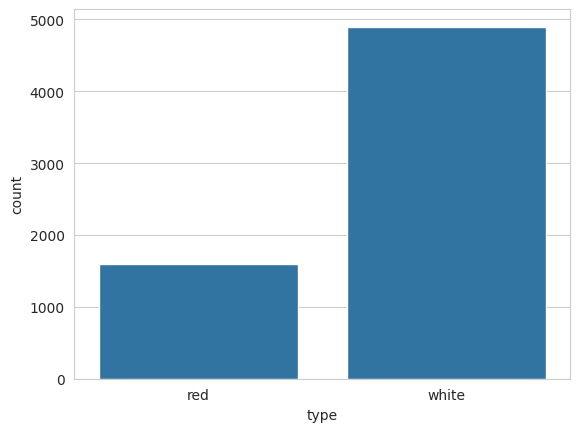

In [32]:
sns.set_style('whitegrid')
sns.countplot(data, x = 'type')

Анализ диаграммы показывает, что набор данных является несбалансированным

In [33]:

print("Количество строк:", data.shape[0])
print("Количество столбцов:", data.shape[1])

data.describe()


Количество строк: 6497
Количество столбцов: 13


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


In [34]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  type                  6497 non-null   object 
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB


##Проверяем наличие пропущенных значений и выбросов


In [35]:
print(data.isnull().sum())

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
type                    0
dtype: int64


В датасете нет нулевых значений



###Проверим датасет на выбросы:

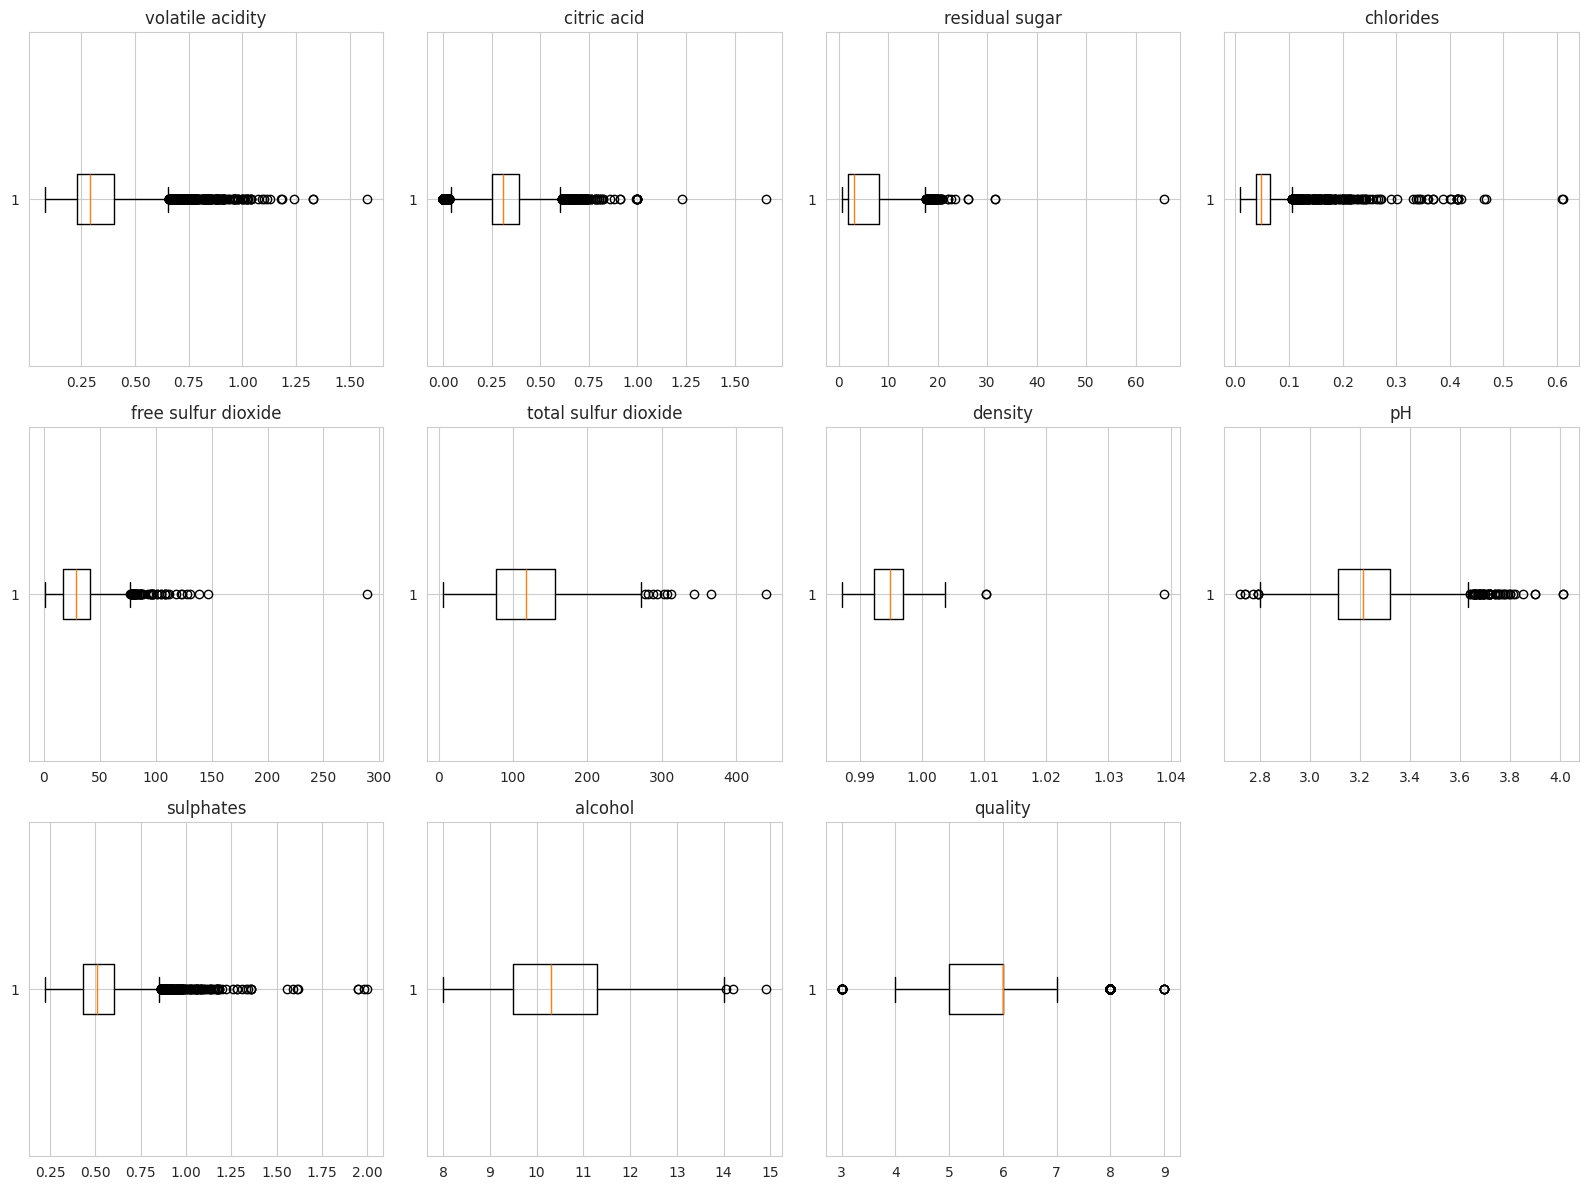

In [36]:
plt.figure(figsize=(16, 12))
for i, col in enumerate(['volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol','quality'], 1):
    plt.subplot(3, 4, i)
    plt.boxplot(data[col], vert=False)
    plt.title(col)
plt.tight_layout()
plt.show()

По диаграммам видно, что критериями с наименьшим количеством выбросов являются:
* quality
* alcohol
* density
* total sulfur dioxide
* residual sugar

Отчистим выбросы в наиболее критичных критериях

In [37]:
cols = ['fixed acidity', 'volatile acidity', 'citric acid', 'chlorides', 'free sulfur dioxide','total sulfur dioxide', 'pH', 'sulphates']
data_clean = data.copy()
for col in cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    data_clean = data_clean[(data_clean[col] >= lower) & (data_clean[col] <= upper)]



In [38]:
print(f"Было строк: {len(data)}")
print(f"Стало строк: {len(data_clean)}")
print(f"Удалено: {len(data) - len(data_clean)} строк ({100 * (len(data) - len(data_clean)) / len(data):.1f}%)")

Было строк: 6497
Стало строк: 5131
Удалено: 1366 строк (21.0%)


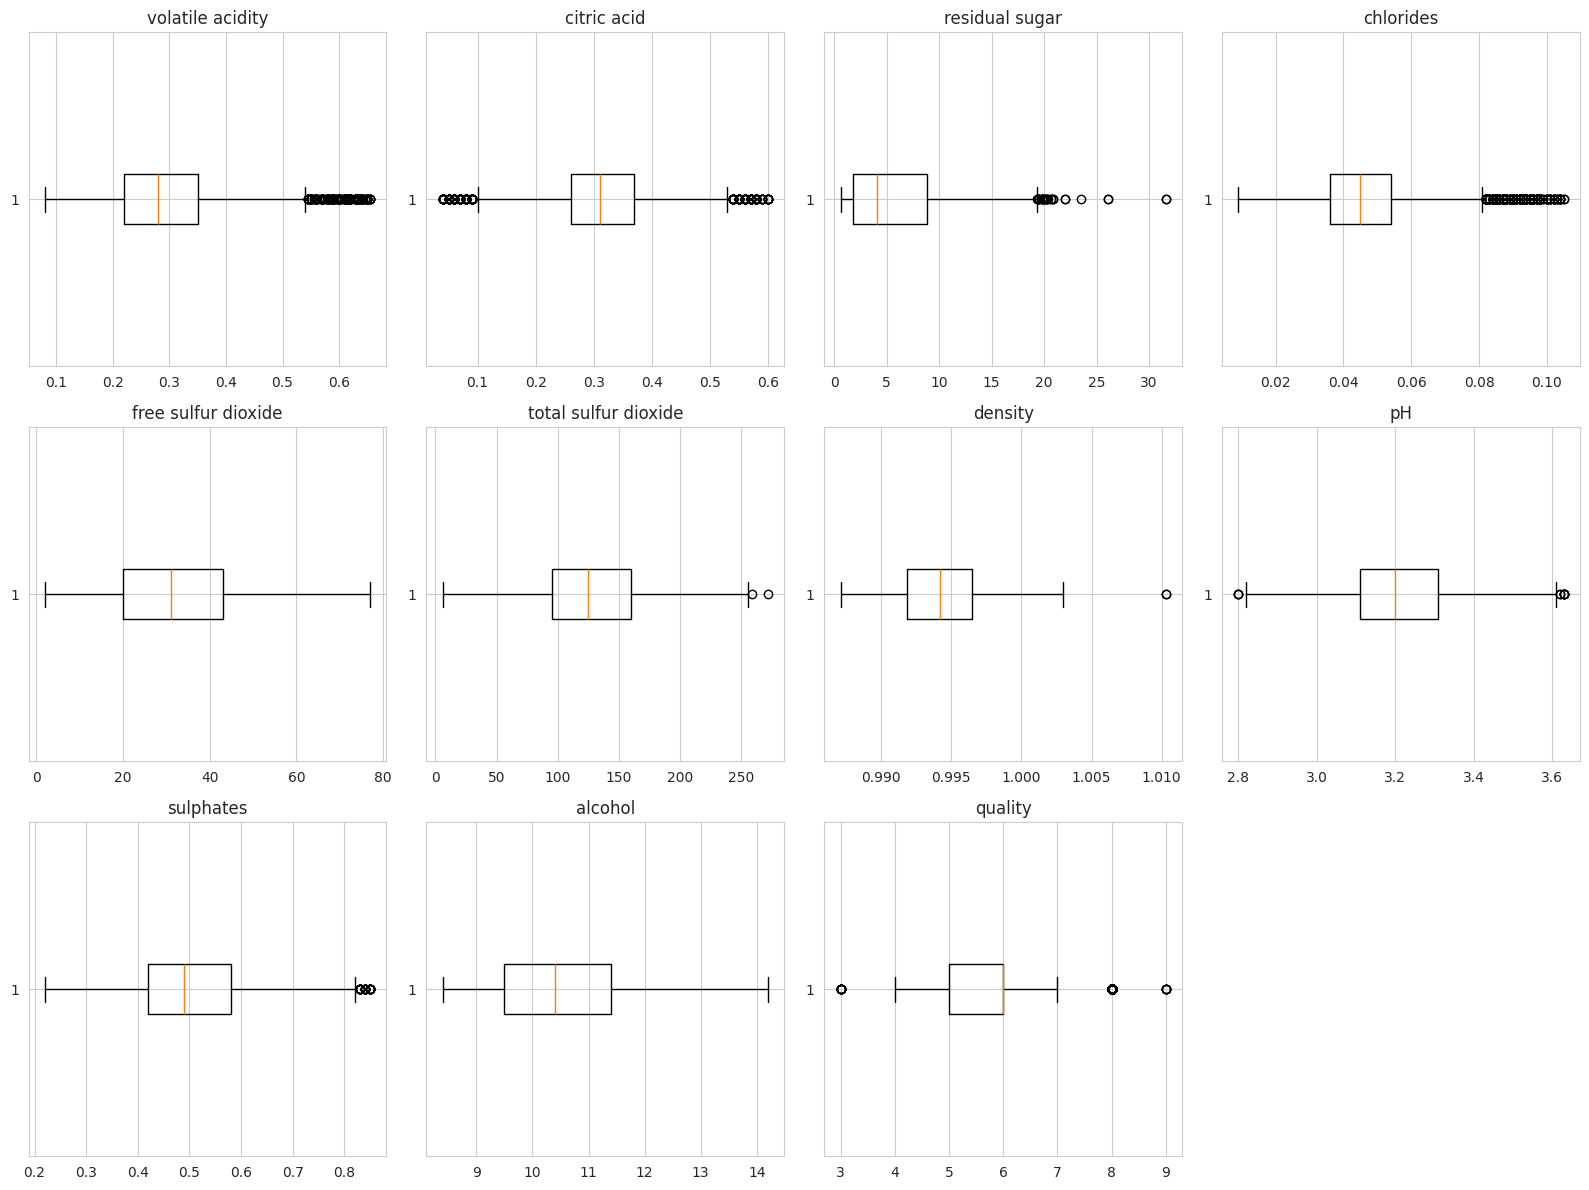

In [39]:
plt.figure(figsize=(16, 12))
for i, col in enumerate(['volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol','quality'], 1):
    plt.subplot(3, 4, i)
    plt.boxplot(data_clean[col], vert=False)
    plt.title(col)
plt.tight_layout()
plt.show()

#Исключаем невлияющие категориальные признаки

Проверим категориальные признаки на уникальность

In [40]:
print(data['quality'].nunique())

7


Категориальный признак type является целевым, поэтому делаем вывод, что невлияющих категориальных признаков, в представленном датафрейме нет.

Преобразуем все оставшиеся признаки в числовые

In [41]:
data_copy = data_clean.copy()
data_copy['type'] = data_copy['type'].astype('category').cat.codes
data_copy.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
6,7.9,0.60,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5,0
9,7.5,0.50,0.36,6.1,0.071,17.0,102.0,0.9978,3.35,0.80,10.5,5,0
10,6.7,0.58,0.08,1.8,0.097,15.0,65.0,0.9959,3.28,0.54,9.2,5,0
11,7.5,0.50,0.36,6.1,0.071,17.0,102.0,0.9978,3.35,0.80,10.5,5,0
16,8.5,0.28,0.56,1.8,0.092,35.0,103.0,0.9969,3.30,0.75,10.5,7,0


##Разделяем данные на признаки и целевую переменную

In [42]:
y = data_copy['type']
X = data_copy.drop('type', axis = 1)
X

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
6,7.9,0.60,0.06,1.6,0.069,15.0,59.0,0.99640,3.30,0.46,9.4,5
9,7.5,0.50,0.36,6.1,0.071,17.0,102.0,0.99780,3.35,0.80,10.5,5
10,6.7,0.58,0.08,1.8,0.097,15.0,65.0,0.99590,3.28,0.54,9.2,5
11,7.5,0.50,0.36,6.1,0.071,17.0,102.0,0.99780,3.35,0.80,10.5,5
16,8.5,0.28,0.56,1.8,0.092,35.0,103.0,0.99690,3.30,0.75,10.5,7
...,...,...,...,...,...,...,...,...,...,...,...,...
6492,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6
6493,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5
6494,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6
6495,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7


##Применяем операцию нормализации для численной устойчивости

In [43]:

from sklearn.preprocessing import StandardScaler
standardizer = StandardScaler()
X = standardizer.fit_transform(X)
X

array([[ 1.06951623,  2.64964833, -2.55194262, ..., -0.38301639,
        -0.94816605, -1.02462117],
       [ 0.61209933,  1.77252077,  0.43508129, ...,  2.55187801,
        -0.03494056, -1.02462117],
       [-0.30273448,  2.47422282, -2.35280769, ...,  0.307547  ,
        -1.11420705, -1.02462117],
       ...,
       [-0.53144293, -0.50801088, -1.25756559, ..., -0.38301639,
        -0.94816605,  0.13645021],
       [-1.67498519, -0.0694471 , -0.16232349, ..., -1.07357978,
         1.87453092,  1.2975216 ],
       [-1.10321406, -0.77114915,  0.63421622, ..., -1.59150232,
         1.04432593,  0.13645021]])

##Разделяем данные на тренировочный и тестовые наборы
80% данных используется для обучения и 20% для тестирования

In [44]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=0)

##Обучаем модель логистической регрессии

Применяем автоматическое определение весов классов - class_weight='balanced', так как наш датафрейм несбалансированный

In [45]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(class_weight='balanced')
model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced')

##Делаем прогноз на основе данных тестировани

In [46]:
y_pred = model.predict(X_test)

##Рассчитываем показатели точности, сравнив фактичнеские и прогнозируемые значения

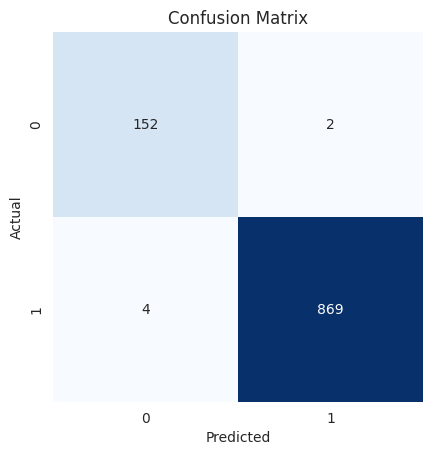

In [47]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, square=True, annot=True, fmt='d', cbar=False, cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [48]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print(f"Точность: {accuracy:.2f}")

Точность: 0.99


In [49]:
from sklearn.metrics import precision_score, recall_score
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
print(f"Точность: {precision:.2f}")
print(f"Полнота: {recall:.2f}")


Точность: 1.00
Полнота: 1.00


In [50]:
from sklearn.metrics import f1_score
f1 = f1_score(y_test, y_pred)
print(f"F1-мера: {f1:.2f}")

F1-мера: 1.00


In [51]:
data_copy.corr()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
fixed acidity,1.000000,0.149804,0.239913,-0.036524,0.313172,-0.171260,-0.148096,0.326692,-0.248586,0.133645,-0.107617,-0.097119,-0.340481
volatile acidity,0.149804,1.000000,-0.319669,-0.116391,0.422727,-0.282603,-0.265339,0.166883,0.181557,0.173548,-0.001831,-0.202929,-0.566315
citric acid,0.239913,-0.319669,1.000000,0.091595,-0.116686,0.142674,0.173252,0.034712,-0.177425,0.021145,0.036111,0.069013,0.177033
residual sugar,-0.036524,-0.116391,0.091595,1.000000,-0.032055,0.406844,0.474143,0.688253,-0.258247,-0.131083,-0.420997,-0.063437,0.275459
chlorides,0.313172,0.422727,-0.116686,-0.032055,1.000000,-0.183468,-0.225327,0.506316,0.199709,0.305552,-0.394130,-0.271566,-0.691223
free sulfur dioxide,-0.171260,-0.282603,0.142674,0.406844,-0.183468,1.000000,0.681522,0.181489,-0.129464,-0.100764,-0.210138,0.060302,0.378672
total sulfur dioxide,-0.148096,-0.265339,0.173252,0.474143,-0.225327,0.681522,1.000000,0.252029,-0.200343,-0.156596,-0.339584,-0.090144,0.586975
density,0.326692,0.166883,0.034712,0.688253,0.506316,0.181489,0.252029,1.000000,0.025246,0.179018,-0.778006,-0.317203,-0.268562
pH,-0.248586,0.181557,-0.177425,-0.258247,0.199709,-0.129464,-0.200343,0.025246,1.000000,0.274164,0.069001,0.040729,-0.335738
sulphates,0.133645,0.173548,0.021145,-0.131083,0.305552,-0.100764,-0.156596,0.179018,0.274164,1.000000,-0.028363,0.037007,-0.406147


##Строим ROC-кривую

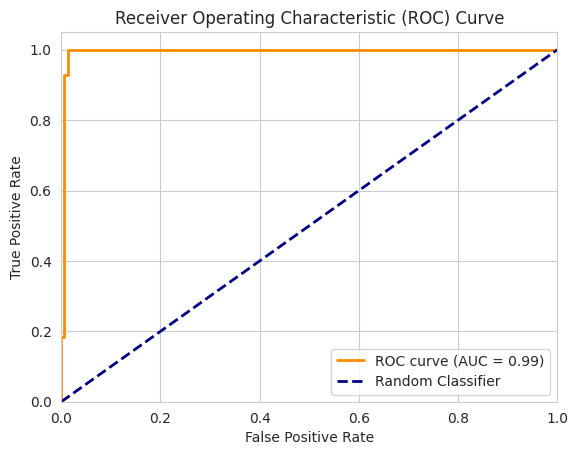

In [52]:
from sklearn.metrics import roc_curve, auc

y_score = model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_score)

roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()
